# Exercício EDA - Felipe Tagawa

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd "/content/drive/MyDrive/DATASET IRIS AULA 3"

/content/drive/MyDrive/DATASET IRIS AULA 3


In [5]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

In [6]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df.rename(columns={"target":"species_id"}, inplace=True)

df["species"] = iris.target_names[df["species_id"]]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [7]:
display(df.describe())

display(df.shape)
display(df.columns)

display(df.info())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


(150, 6)

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species_id', 'species'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species_id         150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


None

## Verificar balanceamento

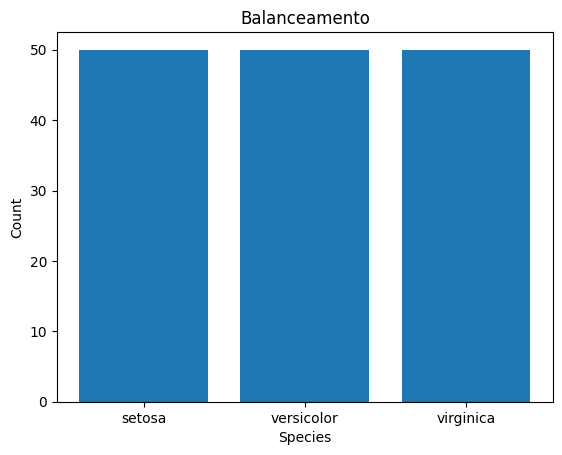

In [8]:
plt.bar(df["species"].unique(), df["species"].value_counts())
plt.title("Balanceamento")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

## Verificar valores nulos ou duplicados

In [9]:
print(df.isnull().sum())
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print(df.duplicated().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species_id           0
species              0
dtype: int64
1
0


## Gráficos

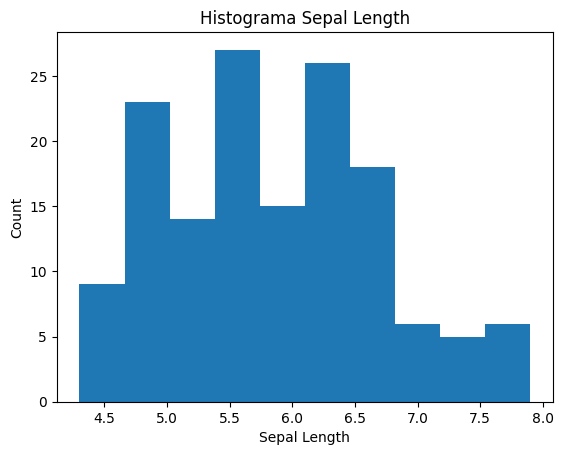

In [10]:
plt.hist(df["sepal length (cm)"])
plt.title("Histograma Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Count")
plt.show()

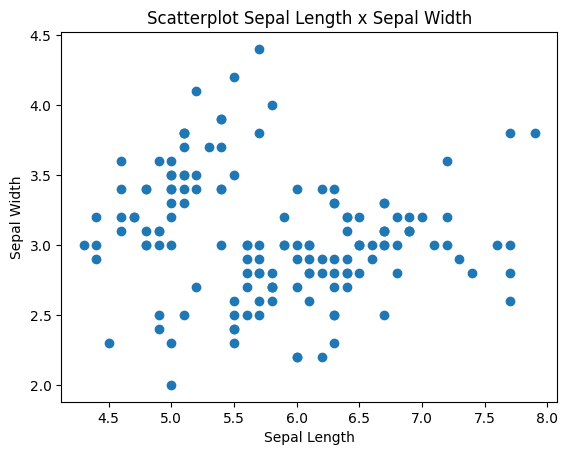

In [12]:
plt.scatter(df["sepal length (cm)"], df["sepal width (cm)"])
plt.title("Scatterplot Sepal Length x Sepal Width")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()

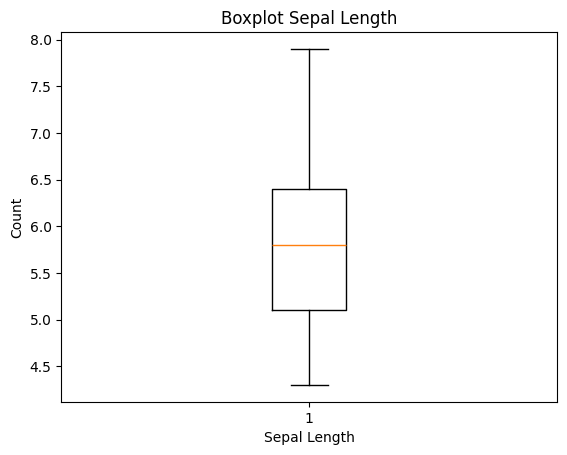

In [13]:
plt.boxplot(df["sepal length (cm)"])
plt.title("Boxplot Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Count")
plt.show()

## Variáveis Numéricas

In [23]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

df = pd.get_dummies(df, columns=cat_cols, dtype=int)

df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species_setosa,species_versicolor,species_virginica
sepal length (cm),1.000000,-0.118129,0.873738,0.820620,0.786971,-0.718879,0.079280,0.642853
sepal width (cm),-0.118129,1.000000,-0.426028,-0.362894,-0.422987,0.601821,-0.473476,-0.128997
petal length (cm),0.873738,-0.426028,1.000000,0.962772,0.949402,-0.922494,0.206123,0.720018
petal width (cm),0.820620,-0.362894,0.962772,1.000000,0.956514,-0.886988,0.122833,0.768044
species_id,0.786971,-0.422987,0.949402,0.956514,1.000000,-0.866030,0.005852,0.864556
species_setosa,-0.718879,0.601821,-0.922494,-0.886988,-0.866030,1.000000,-0.505051,-0.497468
species_versicolor,0.079280,-0.473476,0.206123,0.122833,0.005852,-0.505051,1.000000,-0.497468
species_virginica,0.642853,-0.128997,0.720018,0.768044,0.864556,-0.497468,-0.497468,1.000000
